<a href="https://colab.research.google.com/github/jfdmd/Deep-learning/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Image Compression using SVD on Olivetti Faces Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from numpy.linalg import svd

In [2]:
# Load the Olivetti faces dataset
faces = fetch_olivetti_faces()
images = faces.images
print(f"Dataset loaded. Shape of images: {images.shape}")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Dataset loaded. Shape of images: (400, 64, 64)


Next, I'll define a function that performs SVD on an image matrix, reconstructs it using the top `k` singular values, and calculates the mean $\ell_1$ reconstruction error.

In [3]:
def svd_compress_and_error(image_matrix, k):
    """
    Performs SVD on an image matrix, reconstructs it using the top k singular values,
    and calculates the mean L1 reconstruction error.

    Args:
        image_matrix (np.array): The original image matrix (m x n).
        k (int): The number of singular values to use for approximation.

    Returns:
        tuple: A tuple containing:
            - A (np.array): The rank-k approximated image matrix.
            - error_l1 (float): The mean L1 reconstruction error.
    """
    U, s, Vt = svd(image_matrix, full_matrices=False)

    # Reconstruct the image using the top k singular values
    s_k = np.zeros((k, k))
    s_k[:k, :k] = np.diag(s[:k])

    A = U[:, :k] @ s_k @ Vt[:k, :]

    # Calculate mean L1 error
    m, n = image_matrix.shape
    error_l1 = np.sum(np.abs(image_matrix - A)) / (m * n)

    return A, error_l1

Now, I will iterate through different values of `k` (from 1 to 30) to calculate the average reconstruction error across all images in the dataset.

In [4]:
k_values = range(1, 31) # k from 1 to 30
average_errors = []

for k in k_values:
    errors_for_k = []
    for i in range(images.shape[0]):
        _, error = svd_compress_and_error(images[i], k)
        errors_for_k.append(error)
    average_errors.append(np.mean(errors_for_k))

print("Average reconstruction errors calculated for k values.")

Average reconstruction errors calculated for k values.


Finally, I'll plot the average reconstruction error as a function of `k`.

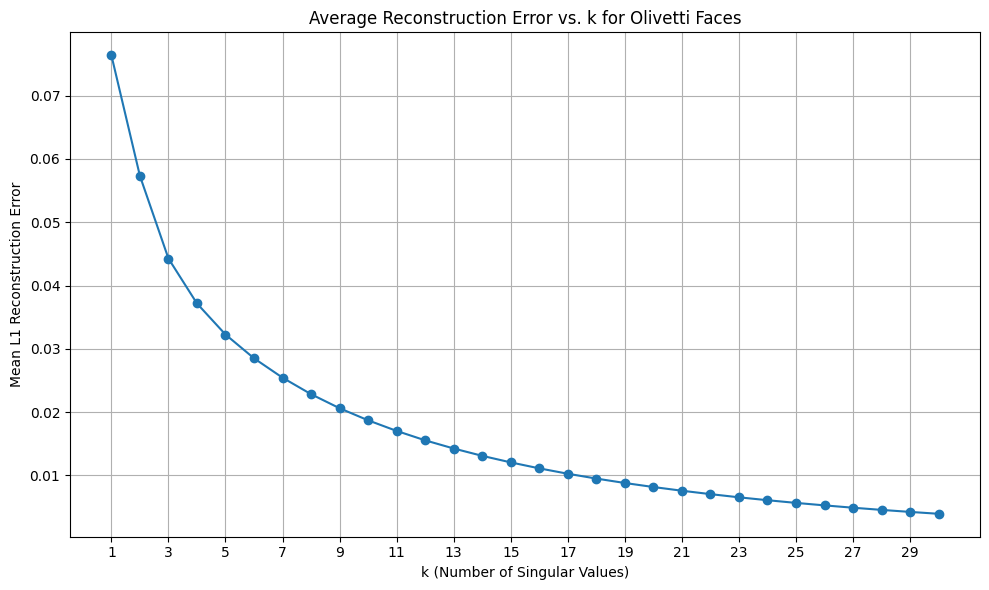

In [5]:
fig = plt.figure(figsize=(10, 6))
plt.plot(k_values, average_errors, marker='o', linestyle='-')
plt.title('Average Reconstruction Error vs. k for Olivetti Faces')
plt.xlabel('k (Number of Singular Values)')
plt.ylabel('Mean L1 Reconstruction Error')
plt.grid(True)
plt.xticks(np.arange(min(k_values), max(k_values)+1, 2)) # Show ticks for every 2 k values
plt.tight_layout()
plt.show()

### Visualizing Image Compression

Let's pick an image and see how its rank-k approximations look for different values of `k`.

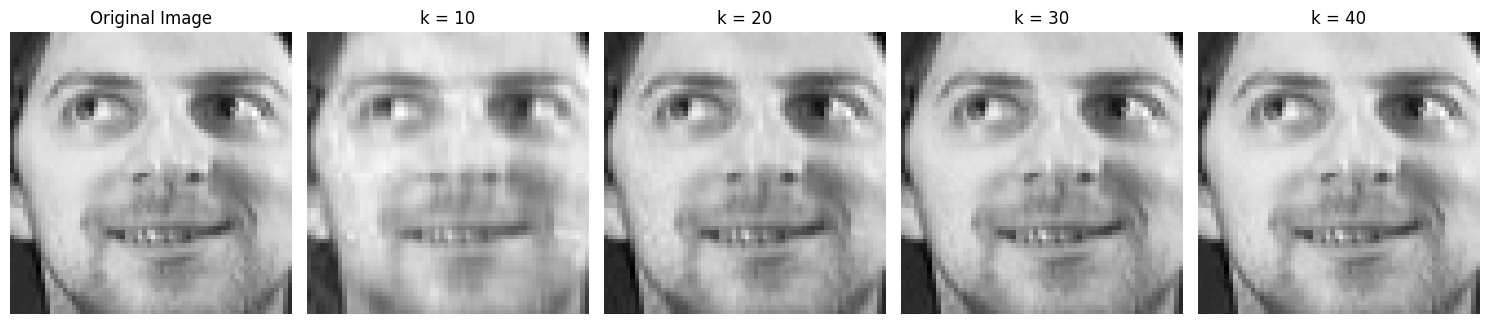

In [6]:
# Pick a random image from the dataset
image_index = np.random.randint(0, images.shape[0])
original_image = images[image_index]

# Define the k values for approximation
k_values_display = [10, 20, 30, 40]
approximated_images = []

for k_val in k_values_display:
    approximated_img, _ = svd_compress_and_error(original_image, k_val)
    approximated_images.append(approximated_img)

# Create a figure to display the images
fig, axes = plt.subplots(1, 1 + len(k_values_display), figsize=(15, 5))

# Display the original image
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

# Display the approximated images
for i, (k_val, approx_img) in enumerate(zip(k_values_display, approximated_images)):
    axes[i + 1].imshow(approx_img, cmap='gray')
    axes[i + 1].set_title(f'k = {k_val}')
    axes[i + 1].axis('off')

plt.tight_layout()
plt.show()

## Principal Component Analysis (PCA) on Wisconsin Breast Cancer Dataset

Now, let's switch gears and work on visualizing the Wisconsin breast cancer dataset using PCA. We'll rescale the data, compute principal components using two different methods, and then plot the results.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [8]:
# Load the Wisconsin breast cancer dataset
breast_cancer = load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target
target_names = breast_cancer.target_names
feature_names = breast_cancer.feature_names

print(f"Dataset loaded. X shape: {X.shape}, y shape: {y.shape}")

Dataset loaded. X shape: (569, 30), y shape: (569,)


First, we need to rescale the data so that every feature has a mean of 0 and a standard deviation of 1. This is crucial for PCA, as features with larger variances would otherwise dominate the principal components.

In [9]:
# Rescale the data using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data rescaled. First 5 rows of scaled data:")
print(X_scaled[:5])

Data rescaled. First 5 rows of scaled data:
[[ 1.09706398e+00 -2.07333501e+00  1.26993369e+00  9.84374905e-01
   1.56846633e+00  3.28351467e+00  2.65287398e+00  2.53247522e+00
   2.21751501e+00  2.25574689e+00  2.48973393e+00 -5.65265059e-01
   2.83303087e+00  2.48757756e+00 -2.14001647e-01  1.31686157e+00
   7.24026158e-01  6.60819941e-01  1.14875667e+00  9.07083081e-01
   1.88668963e+00 -1.35929347e+00  2.30360062e+00  2.00123749e+00
   1.30768627e+00  2.61666502e+00  2.10952635e+00  2.29607613e+00
   2.75062224e+00  1.93701461e+00]
 [ 1.82982061e+00 -3.53632408e-01  1.68595471e+00  1.90870825e+00
  -8.26962447e-01 -4.87071673e-01 -2.38458552e-02  5.48144156e-01
   1.39236330e-03 -8.68652457e-01  4.99254601e-01 -8.76243603e-01
   2.63326966e-01  7.42401948e-01 -6.05350847e-01 -6.92926270e-01
  -4.40780058e-01  2.60162067e-01 -8.05450380e-01 -9.94437403e-02
   1.80592744e+00 -3.69203222e-01  1.53512599e+00  1.89048899e+00
  -3.75611957e-01 -4.30444219e-01 -1.46748968e-01  1.08708430e+

Next, we'll compute the top two principal components in two ways:

**(a) Using SVD directly:** We'll perform Singular Value Decomposition on the scaled data and extract the principal components manually.

In [10]:
# (a) PCA using SVD directly

# Perform SVD on the scaled data
# np.linalg.svd returns U, s, Vt where Vt are the principal components (eigenvectors)
U, s, Vt = np.linalg.svd(X_scaled)

# The principal components are the rows of Vt (or columns of V)
# We need the top two principal components
pc_svd = Vt[:2, :]

# Project the scaled data onto the top two principal components
X_projected_svd = X_scaled @ pc_svd.T

print("PCA with direct SVD completed.")
print("Shape of top 2 principal components (SVD):", pc_svd.shape)
print("Shape of projected data (SVD):", X_projected_svd.shape)

PCA with direct SVD completed.
Shape of top 2 principal components (SVD): (2, 30)
Shape of projected data (SVD): (569, 2)


**(b) Using `sklearn.decomposition.PCA`:** We'll use scikit-learn's built-in PCA function for comparison.

In [11]:
# (b) PCA using sklearn.decomposition.PCA

# Initialize PCA with 2 components
pca_sklearn = PCA(n_components=2)

# Fit PCA to the scaled data and transform it
X_projected_sklearn = pca_sklearn.fit_transform(X_scaled)

# The principal components can be accessed via .components_
pc_sklearn = pca_sklearn.components_

print("PCA with sklearn completed.")
print("Shape of top 2 principal components (sklearn):", pc_sklearn.shape)
print("Shape of projected data (sklearn):", X_projected_sklearn.shape)

PCA with sklearn completed.
Shape of top 2 principal components (sklearn): (2, 30)
Shape of projected data (sklearn): (569, 2)


Now, let's compare the results from both approaches. The principal components might have flipped signs due to the nature of SVD, so we'll check and adjust if necessary to ensure they are identical.

In [12]:
# Compare the principal components (eigenvectors)
# Note: Singular vectors are only determined up to sign, so we might need to flip signs

# Check if the first component is flipped
if np.allclose(pc_svd[0], -pc_sklearn[0], atol=1e-6):
    pc_svd[0] = -pc_svd[0]
    X_projected_svd[:, 0] = -X_projected_svd[:, 0]
    print("Flipped sign of first SVD principal component and projected data.")

# Check if the second component is flipped
if np.allclose(pc_svd[1], -pc_sklearn[1], atol=1e-6):
    pc_svd[1] = -pc_svd[1]
    X_projected_svd[:, 1] = -X_projected_svd[:, 1]
    print("Flipped sign of second SVD principal component and projected data.")

print("\nAre the principal components from SVD and sklearn identical (after potential sign flip)?")
print(np.allclose(pc_svd, pc_sklearn))

print("\nAre the projected data from SVD and sklearn identical (after potential sign flip)?")
print(np.allclose(X_projected_svd, X_projected_sklearn))

# Display a small sample of both projections to visually confirm
print("\nFirst 5 rows of SVD projected data:\n", X_projected_svd[:5])
print("\nFirst 5 rows of sklearn projected data:\n", X_projected_sklearn[:5])

Flipped sign of first SVD principal component and projected data.
Flipped sign of second SVD principal component and projected data.

Are the principal components from SVD and sklearn identical (after potential sign flip)?
True

Are the projected data from SVD and sklearn identical (after potential sign flip)?
True

First 5 rows of SVD projected data:
 [[ 9.19283683  1.94858307]
 [ 2.3878018  -3.76817174]
 [ 5.73389628 -1.0751738 ]
 [ 7.1229532  10.27558912]
 [ 3.93530207 -1.94807157]]

First 5 rows of sklearn projected data:
 [[ 9.19283683  1.94858307]
 [ 2.3878018  -3.76817174]
 [ 5.73389628 -1.0751738 ]
 [ 7.1229532  10.27558912]
 [ 3.93530207 -1.94807157]]


Finally, we will create a scatterplot of the dataset in two dimensions, using the first principal component as the x-axis and the second as the y-axis. The points will be colored by their diagnosis (malignant or benign).

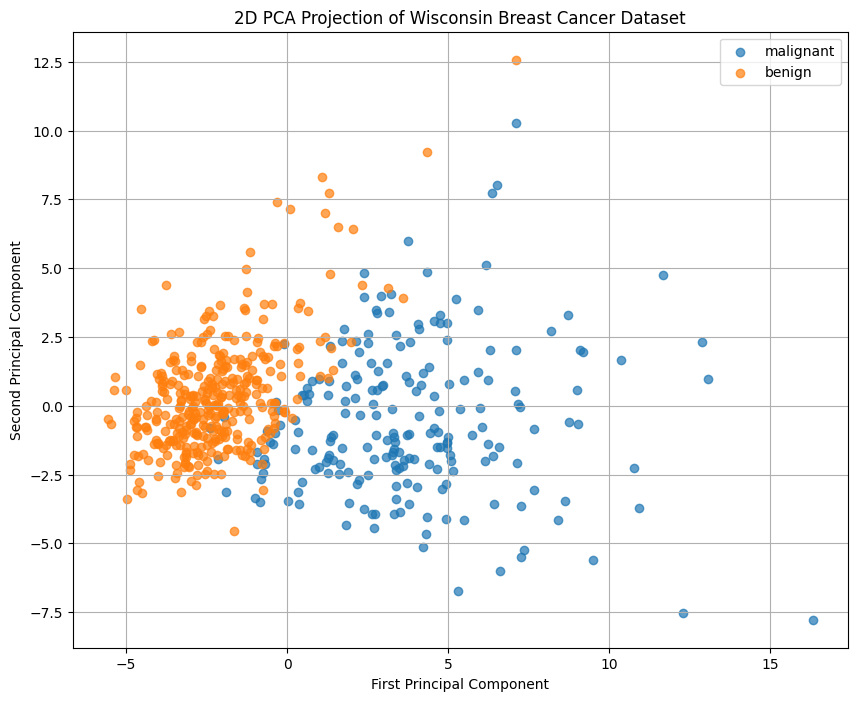

In [13]:
# Create the scatterplot
plt.figure(figsize=(10, 8))

# Plot points for each class
for i, target_name in enumerate(target_names):
    plt.scatter(
        X_projected_sklearn[y == i, 0],
        X_projected_sklearn[y == i, 1],
        label=target_name,
        alpha=0.7
    )

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('2D PCA Projection of Wisconsin Breast Cancer Dataset')
plt.legend()
plt.grid(True)
plt.show()

### PCA Visualization using Direct SVD Results

Let's generate the scatterplot using the projections obtained from the direct SVD method. This should visually confirm that both approaches yield identical results.

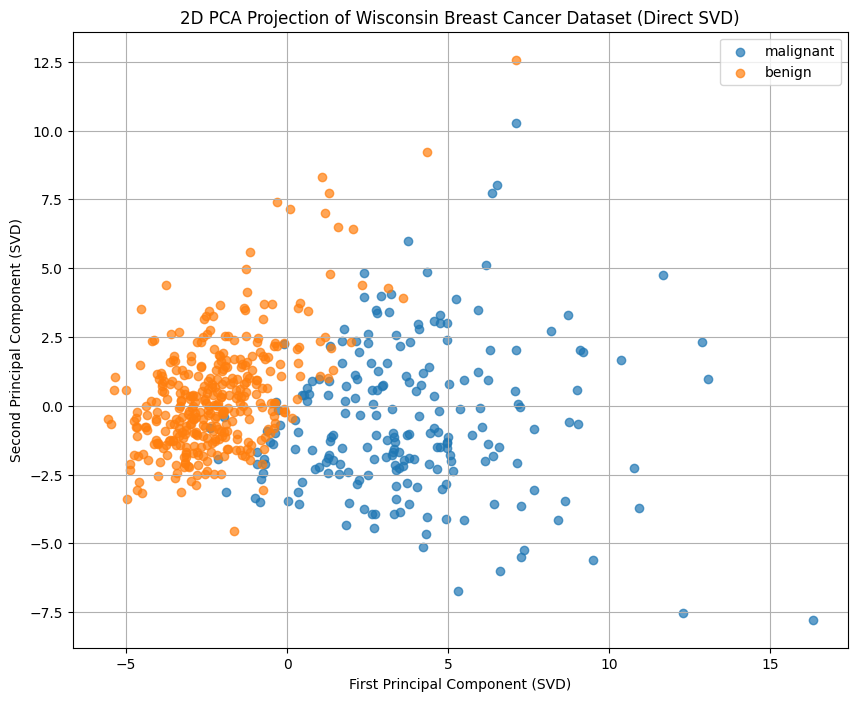

In [14]:
# Create the scatterplot using X_projected_svd
plt.figure(figsize=(10, 8))

# Plot points for each class
for i, target_name in enumerate(target_names):
    plt.scatter(
        X_projected_svd[y == i, 0],
        X_projected_svd[y == i, 1],
        label=target_name,
        alpha=0.7
    )

plt.xlabel('First Principal Component (SVD)')
plt.ylabel('Second Principal Component (SVD)')
plt.title('2D PCA Projection of Wisconsin Breast Cancer Dataset (Direct SVD)')
plt.legend()
plt.grid(True)
plt.show()

### Comparison and Separability Analysis

As you can see from the two plots, they are indeed identical, confirming that both the direct SVD approach and `sklearn.decomposition.PCA` yield the same two principal components and projected data (after accounting for potential sign flips).

Regarding separability, the data does appear to be **roughly separable** in these two dimensions. The points corresponding to 'malignant' and 'benign' diagnoses form distinct clusters, with some overlap, but a clear boundary could likely be drawn to separate a significant portion of the two classes. This suggests that the first two principal components capture important discriminatory information for the breast cancer diagnosis.